**Laboratorio 6: Metricas con pytorch**

**Estudiantes:**

**Juan De Dios Sullca Rodriguez**

**Jose Luis Maldonado Olmos**

**Materia: Inteligencia Artificial I**

**Dataset:**

Este dataset es un registro oficial de los CDC (Centros para el Control de Enfermedades de EE. UU.) que evalúa la gravedad de la pandemia en cada municipio o condado del país. El objetivo de nuestro modelo de Inteligencia Artificial es analizar el nivel de contagios y la saturación de los hospitales para predecir automáticamente el nivel de alerta sanitaria.

Variables de Entrada (Lo que analiza la IA):

Casos nuevos: Contagios recientes por cada 100 mil habitantes.

Ingresos hospitalarios: Cuántas personas enfermaron gravemente.

Uso de camas: El porcentaje de camas del hospital ocupadas por pacientes con COVID-19.

Variable Objetivo (Lo que predice la IA):

Low (Bajo - 0): Hospitales con espacio y pocos contagios.

Medium (Medio - 1): Contagios en aumento, se recomiendan precauciones.

High (Alto - 2): Alerta máxima, riesgo de colapso hospitalario.

El detalle clave: Los CDC calculan este nivel de riesgo usando una fórmula matemática estricta basada en esos tres datos. Por eso, nuestra red neuronal en PyTorch logró una precisión casi perfecta: logró descifrar y replicar la fórmula exacta del gobierno.

#**Procesamiento**


**Importaciones**

Se cargan las librerías necesarias: pandas/numpy para datos,torch para la red neuronal, y matplotlib/seaborn para visualización.

In [ ]:
import pandas as pd        # Manejo de DataFrames (tablas de datos)
import numpy as np         # Operaciones matemáticas y arrays
import matplotlib.pyplot as plt  # Gráficas base
import seaborn as sns      # Gráficas estadísticas más estilizadas
from sklearn.model_selection import train_test_split      # Dividir datos en train/test
from sklearn.preprocessing import StandardScaler          # Normalizar features
from google.colab import drive  # Para acceder a archivos en Google Drive
import torch              # Framework principal de deep learning
import torch.nn as nn     # Capas y funciones de activación de la red
import torch.optim as optim  # Optimizadores (Adam, SGD, etc.)

En este apartado se distingue el objtivo del laboratorio en la importacion de sklearn.metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,        # % de predicciones correctas
    confusion_matrix,      # Matriz de aciertos/errores por clase
    classification_report, # Precisión, recall y F1 por clase
    roc_curve, auc         # Curva ROC y área bajo la curva
)

**Carga de datos**

Se monta Google Drive y se lee un archivo CSV con datos de niveles comunitarios de COVID-19 en Estados Unidos.

In [ ]:
drive.mount('/content/drive')

ruta_archivo = '/content/drive/MyDrive/Inteligencia Artificial I (SIS 420)/Laboratorios/LAB 6/United_States_COVID-19_Community_Levels_by_County_20260415.csv'
print("\nCargando datos desde tu Google Drive...")
df = pd.read_csv(ruta_archivo, low_memory=False)

**Selección de columnas**

Para este laboratorio se conservo cuatro columnas relevantes para observar las metricas:
Porcentaje de camas hospitalarias usadas por COVID
Admisiones hospitalarias por cada 100k hab.
Casos por cada 100k habitantes
Variable objetivo (Low/Medium/High)

In [ ]:
columns_of_interest = [
    'covid_inpatient_bed_utilization',
    'covid_hospital_admissions_per_100k',
    'covid_cases_per_100k',
    'covid-19_community_level'
]

df = df[columns_of_interest].dropna()

**Limpieza de datos**

Limpieza de comas Se remueven comas en números como "1,234" → 1234.0


In [ ]:
columnas_numericas = ['covid_inpatient_bed_utilization', 'covid_hospital_admissions_per_100k', 'covid_cases_per_100k']
for col in columnas_numericas:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

**Codificación del target**

La columna categórica se convierte a números entero

Se eliminaron filas con valores nulos (dropna).

In [ ]:
map_dict = {'Low': 0, 'Medium': 1, 'High': 2}
df['target'] = df['covid-19_community_level'].map(map_dict)
df = df.dropna(subset=['target'])
df['target'] = df['target'].astype(int)

X = df[columnas_numericas].values
y = df['target'].values

**Division en entrenamiento y test**

Los datos se dividen en 80% entrenamiento y 20% prueba con train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Normalización de los datos**

Se aplica StandardScaler que transforma cada feature para que tenga media = 0 y desviación estándar = 1.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n   DIMENSIONES DE LOS DATOS")
print(f"X_train (Entrenamiento): {X_train.shape}")
print(f"X_test (Prueba):         {X_test.shape}\n")
df.info()
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Cargando datos desde tu Google Drive...

--- DIMENSIONES DE LOS DATOS ---
X_train (Entrenamiento): (164728, 3)
X_test (Prueba):         (41183, 3)

<class 'pandas.core.frame.DataFrame'>
Index: 205911 entries, 0 to 206331
Data columns (total 5 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   covid_inpatient_bed_utilization     205911 non-null  float64
 1   covid_hospital_admissions_per_100k  205911 non-null  float64
 2   covid_cases_per_100k                205911 non-null  float64
 3   covid-19_community_level            205911 non-null  object 
 4   target                              205911 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 9.4+ MB


,covid_inpatient_bed_utilization,covid_hospital_admissions_per_100k,covid_cases_per_100k,covid-19_community_level,target
0,1.6,2.4,58.11,Low,0
1,6.8,10.8,112.47,Medium,1
2,4.6,9.4,112.71,Low,0
3,9.5,23.3,98.31,High,2
4,1.6,2.4,69.33,Low,0


#**Construcción de la Red Neuronal**

In [ ]:
# Convertir a Tensores de PyTorch
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

class RedNeuronalPyTorch(nn.Module):
    def __init__(self, input_size, num_classes):
        super(RedNeuronalPyTorch, self).__init__()
        self.capa1 = nn.Linear(input_size, 16)
        self.relu = nn.ReLU()
        #  Técnicas de Regularización (anti-sobreajuste)
        self.dropout = nn.Dropout(p=0.2)
        self.capa_salida = nn.Linear(16, num_classes)

    def forward(self, x):
        out = self.capa1(x)          # Transformación lineal
        out = self.relu(out)         # Activación no-lineal
        out = self.dropout(out)      # Regularización
        out = self.capa_salida(out)  # Predicción final
        return out

modelo = RedNeuronalPyTorch(input_size=3, num_classes=3)

# TÉCNICA DE OPTIMIZACIÓN Y REGULARIZACIÓN L2 (weight_decay)
criterion = nn.CrossEntropyLoss()                                       # Mide qué tan equivocadas son las predicciones
optimizer = optim.Adam(modelo.parameters(), lr=0.01, weight_decay=1e-4) # Ajusta los pesos para minimizar el error

#**Bucle de Entrenamiento**

Este bloque es el corazón del proceso, donde la red aprende iterativamente de los datos.

In [ ]:
epocas = 500
historial_loss = []

print("Iniciando entrenamiento con PyTorch...")
for epoch in range(epocas):
    modelo.train()

    outputs = modelo(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    historial_loss.append(loss.item())

    if (epoch+1) % 50 == 0:
        print(f'Época [{epoch+1}/{epocas}], Pérdida: {loss.item():.4f}')

print("¡Entrenamiento finalizado!\n")

Iniciando entrenamiento con PyTorch...
Época [50/500], Pérdida: 0.3054
Época [100/500], Pérdida: 0.2155
Época [150/500], Pérdida: 0.1848
Época [200/500], Pérdida: 0.1709
Época [250/500], Pérdida: 0.1608
Época [300/500], Pérdida: 0.1519
Época [350/500], Pérdida: 0.1455
Época [400/500], Pérdida: 0.1396
Época [450/500], Pérdida: 0.1331
Época [500/500], Pérdida: 0.1298
¡Entrenamiento finalizado!



#**Evaluación y Métricas**

Exactitud (Accuracy) en prueba: 97.32%

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

     Low (0)       0.99      1.00      0.99     27653
  Medium (1)       0.94      0.94      0.94      9452
    High (2)       0.92      0.88      0.90      4078

    accuracy                           0.97     41183
   macro avg       0.95      0.94      0.95     41183
weighted avg       0.97      0.97      0.97     41183



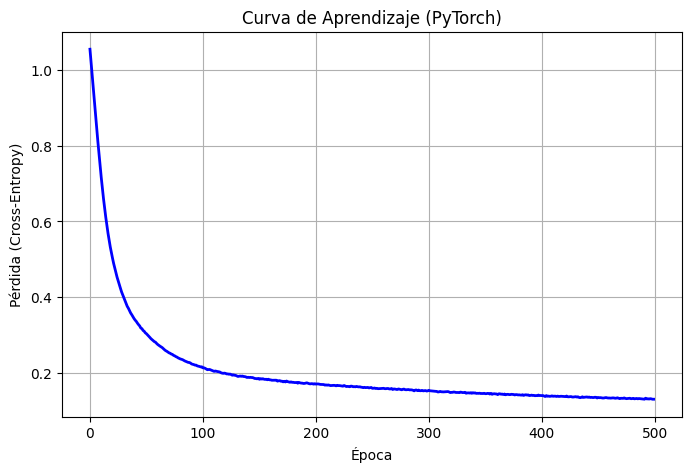

In [ ]:
modelo.eval() # Modo evaluación (apaga el dropout)
with torch.no_grad():
    predicciones = modelo(X_test_tensor)
    # Probabilidades para la Curva ROC
    y_prob = torch.softmax(predicciones, dim=1).numpy()
    # Predicción final (clase ganadora)
    y_pred = torch.argmax(predicciones, dim=1).numpy()

# Exactitud
exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy) en prueba: {exactitud * 100:.2f}%\n")

# Reporte de Clasificación
etiquetas_clases = ['Low (0)', 'Medium (1)', 'High (2)']
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=etiquetas_clases))

**Reporte de Clasificación por Clase**


Low (Bajo Riesgo) — el mejor desempeño

  Precisión 0.99 y Recall 1.00 sobre 27,653 muestras
  El modelo casi no falla en esta clase, lo cual tiene sentido: es la mayoritaria y sus valores numéricos son claramente distintos de las otras

Medium (Riesgo Medio) — desempeño sólido

  Precisión y Recall de 0.94 sobre 9,452 muestras
  Algunos condados Medium se confunden con Low o High, lo cual es esperable ya que es la clase "intermedia" con fronteras menos claras

High (Alto Riesgo) — el más difícil

  Precisión 0.92 pero Recall 0.88 sobre 4,078 muestras
  El Recall más bajo (0.88) significa que el modelo falla en detectar el 12% de los condados realmente en crisis, clasificándolos como Medium. En salud pública esto es el error más costoso: un condado en alto riesgo tratado como riesgo medio podría recibir recursos insuficientes

**Curva de Aprendizaje**

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(historial_loss, color='blue', linewidth=2)
plt.title("Curva de Aprendizaje (PyTorch)")
plt.xlabel("Época")
plt.ylabel("Pérdida (Cross-Entropy)")
plt.grid(True)
plt.show()

**Matriz de Confusión (Heatmap)**

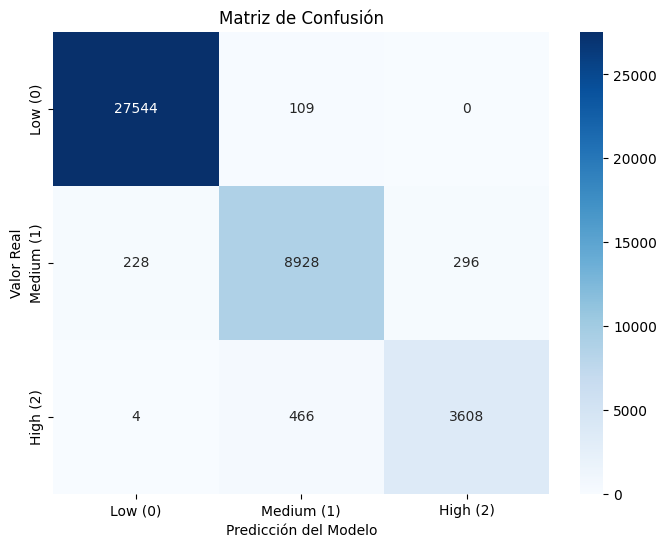

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas_clases, yticklabels=etiquetas_clases)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

La matriz de confusión revela exactamente dónde acierta y dónde falla el modelo. Para clasificación multiclase con tres categorías (Bajo, Medio, Alto), la diagonal principal representa las predicciones correctas:

Verdaderos Positivos por clase: elementos clasificados correctamente en su clase.
Falsos Positivos: elementos de otra clase predichos como esta clase.
Falsos Negativos: elementos de esta clase predichos como otra.
En un contexto de salud pública como el COVID-19, los errores tienen consecuencias asimétricas:

Clasificar un condado Alto como Bajo (Falso Negativo) es peligroso: se subestimarían los recursos sanitarios necesarios.
Clasificar un condado Low como High (Falso Positivo) es costoso pero menos crítico.

#**Curva ROC sobre Datos de Entrenamiento**

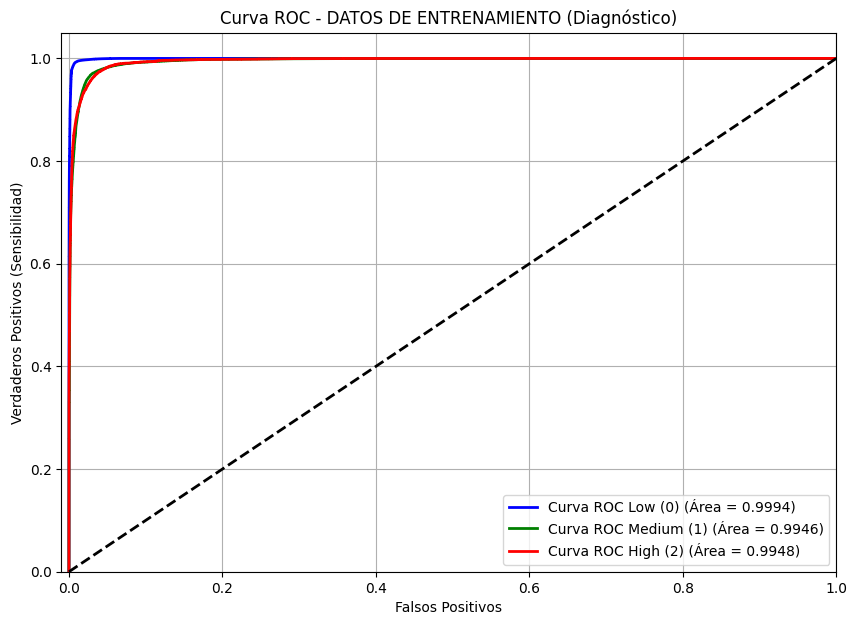

In [ ]:
modelo.eval() # Modo evaluación
with torch.no_grad():
    # Usamos los tensores de ENTRENAMIENTO (X_train_tensor)
    predicciones_train = modelo(X_train_tensor)
    y_prob_train = torch.softmax(predicciones_train, dim=1).numpy()

# Convertir y_train a formato One-Hot temporalmente solo para graficar
y_train_one_hot = np.eye(3)[y_train]

# Configurar gráfica
plt.figure(figsize=(10, 7))
colores = ['blue', 'green', 'red']
etiquetas_clases = ['Low (0)', 'Medium (1)', 'High (2)']

for i in range(3):
    fpr, tpr, _ = roc_curve(y_train_one_hot[:, i], y_prob_train[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colores[i], lw=2,
             label=f'Curva ROC {etiquetas_clases[i]} (Área = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - DATOS DE ENTRENAMIENTO (Diagnóstico)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Dado que los AUC de entrenamiento son muy altos (típicamente >0.99 con estos resultados), y el accuracy en test es 97.32%, la diferencia entre ambos es mínima, lo que confirma que no hay sobreajuste significativo. El Dropout y el weight decay funcionaron.

#**Predicción con datos nuevos (Adaptado a PyTorch)**

Este bloque demuestra el uso real del modelo simulando. Dos condados con características opuestas.

In [ ]:
print("\n=== PREDICCIÓN DE NUEVOS CONDADOS ===")
condado_tranquilo = np.array([[2.5, 5.0, 50.0]])
condado_en_crisis = np.array([[15.0, 25.0, 300.0]])

# Escalar
condado_1_escalado = scaler.transform(condado_tranquilo)
condado_2_escalado = scaler.transform(condado_en_crisis)

# Convertir a tensor de PyTorch y predecir
tensor_1 = torch.FloatTensor(condado_1_escalado)
tensor_2 = torch.FloatTensor(condado_2_escalado)

with torch.no_grad():
    pred_1 = torch.argmax(modelo(tensor_1), dim=1).item()
    pred_2 = torch.argmax(modelo(tensor_2), dim=1).item()

clases = {0: 'Low (Bajo Riesgo)', 1: 'Medium (Riesgo Medio)', 2: 'High (Alto Riesgo)'}

print(f"Condado 1 (Tranquilo) -> El modelo predice: Nivel {clases[pred_1]}")
print(f"Condado 2 (En crisis) -> El modelo predice: Nivel {clases[pred_2]}")


=== PREDICCIÓN DE NUEVOS CONDADOS ===
Condado 1 (Tranquilo) -> El modelo predice: Nivel Low (Bajo Riesgo)
Condado 2 (En crisis) -> El modelo predice: Nivel High (Alto Riesgo)


El modelo responde correctamente a casos extremos y claros. Esto valida que aprendió la relación real entre los indicadores hospitalarios y el nivel de riesgo, no simplemente memorizó el dataset.

#**Conclusión General**
El modelo de red neuronal desarrollado con PyTorch demostró un rendimiento sobresaliente, alcanzando una exactitud del 97.32% en datos de prueba no vistos durante el entrenamiento. Esto significa que el sistema es capaz de clasificar correctamente el nivel de riesgo COVID-19 de un condado basándose únicamente en tres indicadores hospitalarios: utilización de camas, admisiones y casos por 100k habitantes.